In [189]:
# Importing Libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score)

In [190]:
# Loading Dataset
df = pd.read_csv("energydata_complete.csv")
print("Dataset Loaded!")

df.head()

Dataset Loaded!


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [191]:
# Shape of Dataset

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 19735
Columns: 29


In [192]:
# Display Column Names
df.columns

Index(['date', 'Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3',
       'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8',
       'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed',
       'Visibility', 'Tdewpoint', 'rv1', 'rv2'],
      dtype='object')

In [193]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  object 
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float64
 19  T9  

In [194]:
# Check Missing Values
df.isnull().sum()

,0
date,0
Appliances,0
lights,0
T1,0
RH_1,0
T2,0
RH_2,0
T3,0
RH_3,0
T4,0


In [195]:
# Summary of Dataset
df.describe()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,39.026904,...,19.485828,41.552401,7.411665,755.522602,79.750418,4.039752,38.330834,3.760707,24.988033,24.988033
std,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,4.341321,...,2.014712,4.151497,5.317409,7.399441,14.901088,2.451221,11.794719,4.194648,14.496634,14.496634
min,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,27.660000,...,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,35.530000,...,18.000000,38.500000,3.666667,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,38.400000,...,19.390000,40.900000,6.916667,756.100000,83.666667,3.666667,40.000000,3.433333,24.897653,24.897653
75%,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,42.156667,...,20.600000,44.338095,10.408333,760.933333,91.666667,5.500000,40.000000,6.566667,37.583769,37.583769
max,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,51.090000,...,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530


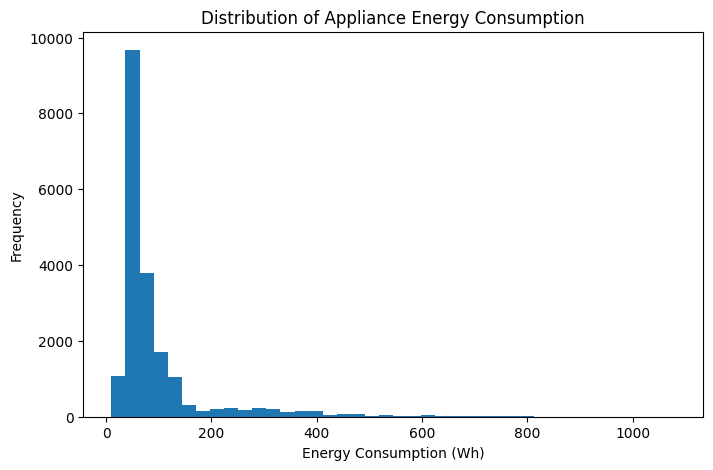

In [196]:
# Histogram of Energy Consumption

plt.figure(figsize=(8,5))
plt.hist(df["Appliances"], bins=40)
plt.title("Distribution of Appliance Energy Consumption")
plt.xlabel("Energy Consumption (Wh)")
plt.ylabel("Frequency")
plt.show()

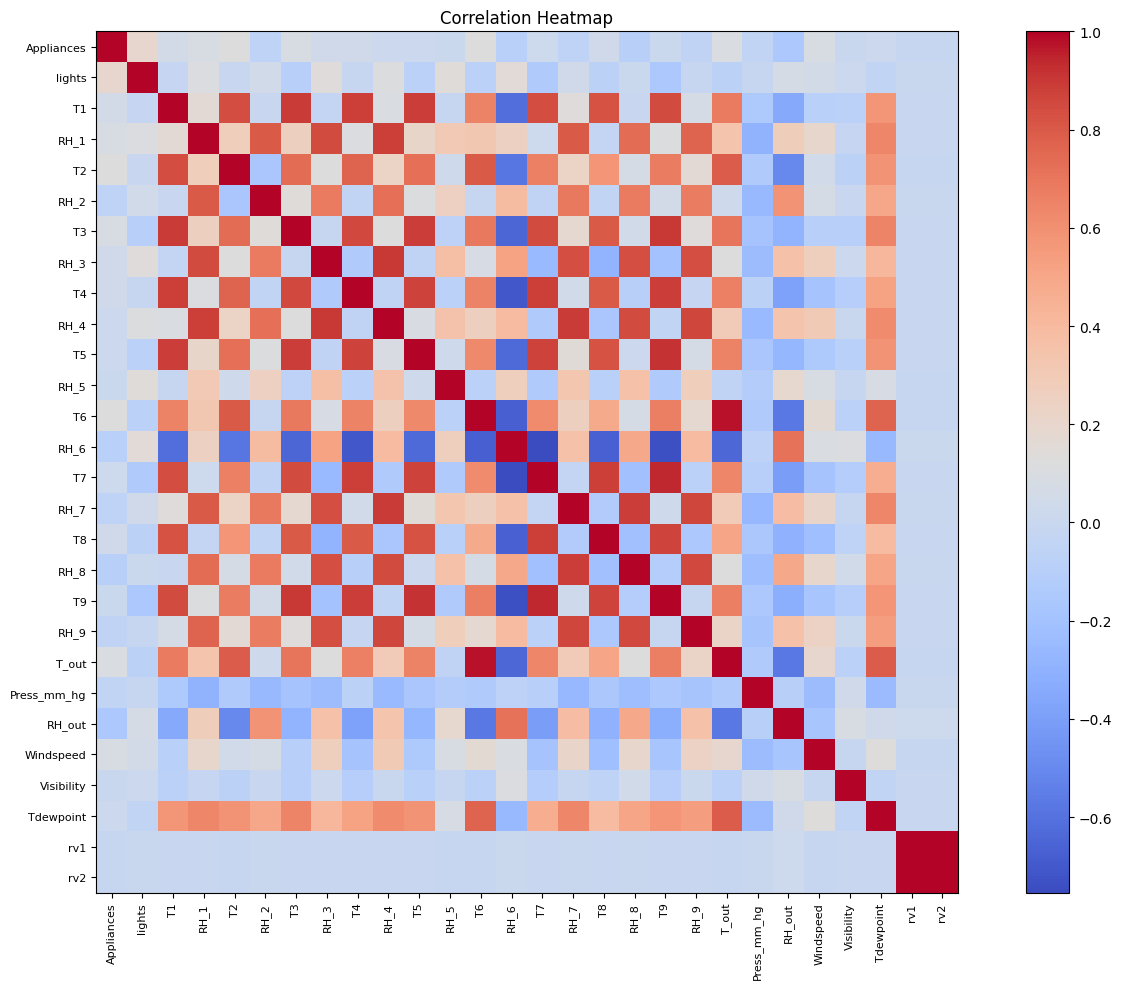

In [197]:
# Correlation Heatmap

plt.figure(figsize=(14,10))
correlation = df.corr(numeric_only=True)
plt.imshow(correlation, cmap="coolwarm")
plt.colorbar()
plt.title("Correlation Heatmap")

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90,
    fontsize=8)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns,
    fontsize=8)

plt.tight_layout()

plt.show()

In [198]:
# Data Cleaning
# Remove unnecessary random variables
df = df.drop(columns=["rv1", "rv2"])

print("Removed rv1 and rv2 (non-informative features).")

# Check again
df.head()

Removed rv1 and rv2 (non-informative features).


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,18.2,48.900000,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,18.2,48.863333,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,18.2,48.730000,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,18.1,48.590000,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,18.1,48.590000,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9


In [199]:
# Date Parsing

df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")

print("Date conversion done.")
print("Missing dates:", df["date"].isnull().sum())

Date conversion done.
Missing dates: 12637


In [200]:
df[df["date"].isnull()]

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint
186,NaT,50,0,19.426667,43.200000,18.700000,43.090000,19.890000,44.900000,19.000000,...,18.700000,51.631250,17.0,46.663333,6.000000,747.400000,80.000000,8.000000,40.000000,2.700000
187,NaT,30,0,19.390000,43.200000,18.700000,43.200000,19.890000,44.845000,19.000000,...,18.725714,51.794286,17.0,46.826667,5.883333,747.533333,81.333333,8.000000,37.833333,2.833333
188,NaT,20,0,19.390000,43.260000,18.700000,43.260000,19.890000,44.863333,18.963333,...,18.790000,51.925000,17.0,46.966667,5.766667,747.666667,82.666667,8.000000,35.666667,2.966667
189,NaT,30,0,19.390000,43.290000,18.690909,43.310000,19.890000,44.790000,18.890000,...,18.750000,52.185556,17.0,47.126667,5.650000,747.800000,84.000000,8.000000,33.500000,3.100000
190,NaT,20,0,19.390000,43.363333,18.677778,43.397778,19.890000,44.790000,18.890000,...,18.815000,52.250000,17.0,47.260000,5.533333,747.933333,85.333333,8.000000,31.333333,3.233333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19730,NaT,100,0,25.566667,46.560000,25.890000,42.025714,27.200000,41.163333,24.700000,...,24.700000,50.074000,23.2,46.790000,22.733333,755.200000,55.666667,3.333333,23.666667,13.333333
19731,NaT,90,0,25.500000,46.500000,25.754000,42.080000,27.133333,41.223333,24.700000,...,24.700000,49.790000,23.2,46.790000,22.600000,755.200000,56.000000,3.500000,24.500000,13.300000
19732,NaT,270,10,25.500000,46.596667,25.628571,42.768571,27.050000,41.690000,24.700000,...,24.700000,49.660000,23.2,46.790000,22.466667,755.200000,56.333333,3.666667,25.333333,13.266667
19733,NaT,420,10,25.500000,46.990000,25.414000,43.036000,26.890000,41.290000,24.700000,...,24.662500,49.518750,23.2,46.817500,22.333333,755.200000,56.666667,3.833333,26.166667,13.233333


In [201]:
# Feature Engineering

df["hour"] = df["date"].dt.hour
df["day_of_week"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

# Droping date column
df = df.drop(columns=["date"])

df.head()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,hour,day_of_week,month,is_weekend
0,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,...,6.600000,733.5,92.0,7.000000,63.000000,5.3,17.0,1.0,11.0,0
1,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,...,6.483333,733.6,92.0,6.666667,59.166667,5.2,17.0,1.0,11.0,0
2,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,...,6.366667,733.7,92.0,6.333333,55.333333,5.1,17.0,1.0,11.0,0
3,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,...,6.250000,733.8,92.0,6.000000,51.500000,5.0,17.0,1.0,11.0,0
4,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,...,6.133333,733.9,92.0,5.666667,47.666667,4.9,17.0,1.0,11.0,0


In [202]:
# Defining Features and Target

X = df.drop(columns=["Appliances"])
y = df["Appliances"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (19735, 29)
y shape: (19735,)


In [203]:
# Handling Missing Values
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")

# keeping column names
feature_names = X.columns
X = imputer.fit_transform(X)

# Converting back to DataFrame
X = pd.DataFrame(X, columns=feature_names)

In [204]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 15788
Test samples: 3947


In [205]:
# Linear Regression Model
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

print("Linear Regression trained!")

Linear Regression trained!


In [206]:
# Predictions on test data

y_pred_lr = lr_model.predict(X_test)

print("Predictions completed!")

Predictions completed!


In [207]:
# Evaluation Metrics

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results:")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

Linear Regression Results:
MAE: 52.45952421633478
RMSE: 91.13143514849835
R2 Score: 0.1700946464699854


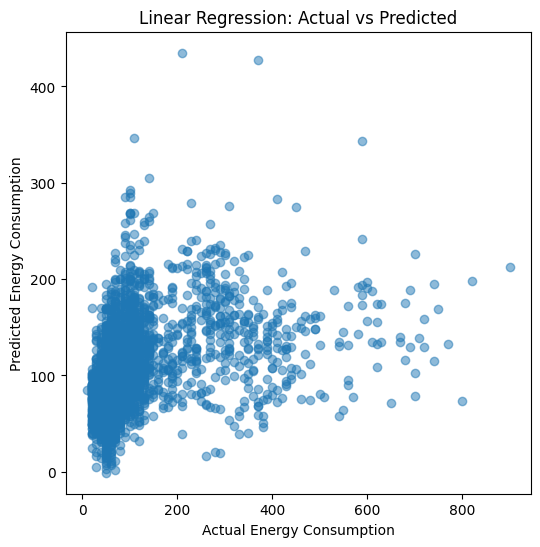

In [208]:
# Plot of Actual vs Predicted

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lr, alpha=0.5)

plt.xlabel("Actual Energy Consumption")
plt.ylabel("Predicted Energy Consumption")
plt.title("Linear Regression: Actual vs Predicted")

plt.show()

In [209]:
# Random Forest Regression

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1)

rf_model.fit(X_train, y_train)

print("Random Forest trained!")

Random Forest trained!


In [210]:
# Predictions

y_pred_rf = rf_model.predict(X_test)

print("Random Forest predictions completed!")

Random Forest predictions completed!


In [211]:
# Evaluation Metrics

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results:")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest Results:
MAE: 31.986344058778823
RMSE: 67.70281459907287
R2 Score: 0.5419576916456691


In [212]:
# Comparing Models

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_lr, mae_rf],
    "RMSE": [rmse_lr, rmse_rf],
    "R2 Score": [r2_lr, r2_rf] })
results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,52.459524,91.131435,0.170095
1,Random Forest,31.986344,67.702815,0.541958


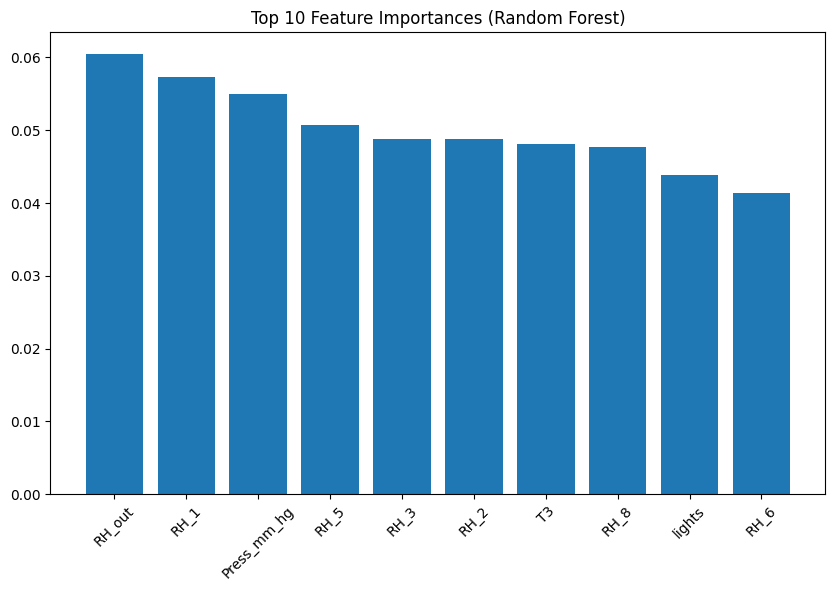

In [213]:
# Feature Importance for Random Forest

importances = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
plt.bar(feature_importance["Feature"][:10], feature_importance["Importance"][:10])
plt.xticks(rotation=45)
plt.title("Top 10 Feature Importances (Random Forest)")
plt.show()

In [214]:
print(results)

               Model        MAE       RMSE  R2 Score
0  Linear Regression  52.459524  91.131435  0.170095
1      Random Forest  31.986344  67.702815  0.541958


In [215]:
if r2_rf > r2_lr:
  best_model = "Random Forest"
else:
  best_model = "Linear Regression"

print("Best Model:", best_model)

Best Model: Random Forest


Final Insights:

1. Random Forest performs better due to nonlinear relationships in energy consumption data.
2. Temperature, humidity, and time-based features significantly impact predictions.
3. Linear Regression serves as a baseline but underfits complex patterns.
4. Feature engineering from time variables improved predictive power.